# 05 — Ensemble samenstellen

Deze notebook hoort bij [`docs/methodologie/ensemble.md`](../docs/methodologie/ensemble.md).
We tonen hoe de modellen (SARIMA-cumulative + ratio) worden gecombineerd via
configureerbare gewichten — en testen op **échte data** of het ensemble de
ratio-baseline echt verslaat.

> ℹ️ De volledige `-d both`-ensemble vereist ook individuele aanmelddata en
> berekent gewichten via grid search. Hier doen we een vereenvoudigde variant:
> SARIMA + ratio met handmatig instelbare gewichten — voldoende om het idee én
> de toegevoegde waarde aan te tonen.


> ⚠️ **De demodata is Radboud (WO).** De voorbeelden gebruiken WO-opleidingen
> (`B Psychologie`, `B Bedrijfskunde`, …). Voor een hogeschool met eigen data:
> 1. Vervang `data/input/vooraanmeldingen_cumulatief.csv` door je eigen ETL-output
> 2. Pas `PROGRAMMA`, `HERKOMST`, `PREDICT_YEAR`, `PREDICT_WEEK` aan naar wat in jouw data zit
> 3. HBO-specifiek: typisch meer numerus-fixus opleidingen, weinig masters, andere 1-mei-deadline-effecten.


In [1]:
# --- Standaard setup voor alle studentprognose-notebooks ---
import sys
from pathlib import Path

# Maak _helpers.py importeerbaar en ga naar projectroot
NOTEBOOKS_DIR = Path.cwd() if Path.cwd().name == "notebooks" else Path.cwd() / "notebooks"
sys.path.insert(0, str(NOTEBOOKS_DIR))

from _helpers import project_root, setup_matplotlib  # noqa: E402
project_root()
setup_matplotlib()

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)

print("Werkmap:", Path.cwd())
print("Python :", sys.version.split()[0])


Werkmap: /home/muhammet/studentprognose
Python : 3.12.12


## 1. Geconfigureerde gewichten uit `configuration.json`

De gewichten staan in de config, per situatie. Ze gelden voor de combinatie
SARIMA-individueel × SARIMA-cumulative (week 38 is altijd 100% individueel).


In [2]:
from studentprognose.config import load_defaults
config = load_defaults()
weights = config.get("ensemble_weights", {})

print("Geconfigureerde ensemble-gewichten:")
for key, w in weights.items():
    print(f"  {key:24s}  individueel={w['individual']:.2f}  cumulatief={w['cumulative']:.2f}")


Geconfigureerde ensemble-gewichten:
  master_week_17_23         individueel=0.20  cumulatief=0.80
  week_30_34                individueel=0.60  cumulatief=0.40
  week_35_37                individueel=0.70  cumulatief=0.30
  default                   individueel=0.50  cumulatief=0.50


In [3]:
from _helpers import load_cumulative

data_cumulative, data_studentcount, data_cumulative_raw = load_cumulative()
print(f"Cumulatieve telregels:    {len(data_cumulative):,}")
print(f"Aantal opleidingen:       {data_cumulative['Croho groepeernaam'].nunique()}")
print(f"Historische realisatie:   {len(data_studentcount):,} rijen (Aantal_studenten per opleiding/jaar)")


Cumulatieve telregels:    25,271
Aantal opleidingen:       18
Historische realisatie:   432 rijen (Aantal_studenten per opleiding/jaar)


## 2. Échte voorspellingen genereren

We draaien de cumulatieve pipeline voor 2023 wk 12 en krijgen **echte**
SARIMA-cumulative en ratio-voorspellingen. Geen fictieve curves.


In [4]:
from studentprognose import run_pipeline_from_dataframes, DataOption
from _helpers import suppress_stdout

PREDICT_YEAR = 2023
PREDICT_WEEK = 12

with suppress_stdout():
    pipeline_out = run_pipeline_from_dataframes(
        year=PREDICT_YEAR, week=PREDICT_WEEK,
        data_cumulative=data_cumulative_raw,
        data_student_numbers=data_studentcount,
        dataset=DataOption.CUMULATIVE, save_output=False,
    )

# Filter eerst op peilweek (SARIMA staat alleen daar; Prognose_ratio voor alle weken)
pl_at_peil = pipeline_out[pipeline_out["Weeknummer"] == PREDICT_WEEK]
agg = (
    pl_at_peil[pl_at_peil["Examentype"] == "Bachelor"]
    .groupby("Croho groepeernaam", as_index=False)
    [["SARIMA_cumulative", "Prognose_ratio"]]
    .sum()
)
real = (
    data_studentcount[(data_studentcount["Examentype"] == "Bachelor")
                      & (data_studentcount["Collegejaar"] == PREDICT_YEAR)]
    .groupby("Croho groepeernaam", as_index=False)
    ["Aantal_studenten"].sum()
    .rename(columns={"Aantal_studenten": "Realisatie"})
)
df = agg.merge(real, on="Croho groepeernaam", how="inner")
print(f"{len(df)} bachelor-opleidingen, voorspeld vanaf peilweek {PREDICT_WEEK} van {PREDICT_YEAR}")
df.head()


12 bachelor-opleidingen, voorspeld vanaf peilweek 12 van 2023


,Croho groepeernaam,SARIMA_cumulative,Prognose_ratio,Realisatie
0,B Bedrijfskunde,352.0,384.553134,421
1,B Biomedische Wetenschappen,237.0,218.142843,266
2,B Communicatiewetenschap,226.0,242.456561,214
3,B Filosofie,78.0,71.141017,84
4,B Geneeskunde,444.0,502.946981,521


## 3. Een ensemble bouwen met instelbare gewichten

Omdat we hier alleen SARIMA-cumulative en ratio hebben (geen individueel),
construeren we een 2-model ensemble. Je kunt `W_SARIMA` aanpassen en zien hoe
de gemiddelde fout verschuift.


In [5]:
def ensemble_eval(w_sarima: float, df_in: pd.DataFrame) -> dict:
    w_ratio = 1 - w_sarima
    ens = w_sarima * df_in["SARIMA_cumulative"] + w_ratio * df_in["Prognose_ratio"]
    mae = (ens - df_in["Realisatie"]).abs().mean()
    mape = ((ens - df_in["Realisatie"]).abs() / df_in["Realisatie"] * 100).mean()
    return {"w_sarima": w_sarima, "MAE": round(mae, 1), "MAPE_%": round(mape, 1)}

# Gridsearch over gewichten
sweep = pd.DataFrame([ensemble_eval(w, df) for w in np.linspace(0, 1, 11)])
sweep


,w_sarima,MAE,MAPE_%
0,0.0,23.4,11.0
1,0.1,23.5,10.8
2,0.2,23.5,10.6
3,0.3,23.5,10.3
4,0.4,23.5,10.1
5,0.5,23.5,9.9
6,0.6,23.6,9.7
7,0.7,23.6,9.5
8,0.8,23.6,9.3
9,0.9,23.8,9.2


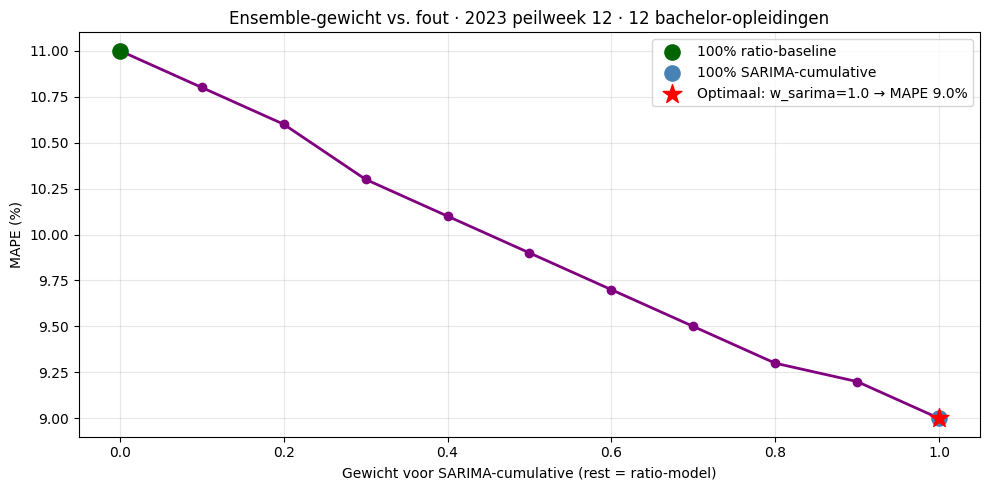


Optimum: {'w_sarima': 1.0, 'MAE': 24.0, 'MAPE_%': 9.0}


In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sweep["w_sarima"], sweep["MAPE_%"], marker="o", color="purple", linewidth=2)

# Markeer de extreme situaties
ax.scatter([0], [sweep[sweep["w_sarima"] == 0.0]["MAPE_%"].iloc[0]],
           color="darkgreen", s=120, zorder=10, label="100% ratio-baseline")
ax.scatter([1], [sweep[sweep["w_sarima"] == 1.0]["MAPE_%"].iloc[0]],
           color="steelblue", s=120, zorder=10, label="100% SARIMA-cumulative")

# Markeer het optimum
opt = sweep.loc[sweep["MAPE_%"].idxmin()]
ax.scatter([opt["w_sarima"]], [opt["MAPE_%"]],
           color="red", s=200, marker="*", zorder=11,
           label=f"Optimaal: w_sarima={opt['w_sarima']:.1f} → MAPE {opt['MAPE_%']:.1f}%")

ax.set_xlabel("Gewicht voor SARIMA-cumulative (rest = ratio-model)")
ax.set_ylabel("MAPE (%)")
ax.set_title(f"Ensemble-gewicht vs. fout · 2023 peilweek 12 · {len(df)} bachelor-opleidingen")
ax.legend()
plt.tight_layout()
plt.show()
print(f"\nOptimum: {opt.to_dict()}")


## 4. Wanneer wint het ensemble — en wanneer niet?

Per opleiding kan een ander optimum gelden. Hieronder kijken we welke opleidingen
**baat hebben bij ensemble** (SARIMA + ratio > beide afzonderlijk) en welke niet.


In [7]:
# Het ensemble (50/50) wint *per definitie* zelden van het beste afzonderlijke model
# voor één opleiding — het is een gemiddelde. De waarde ligt in **stabiliteit**:
# als je vooraf niet weet welk model het best zal presteren, beperkt het ensemble je
# downside. We tonen daarom de SPREAD tussen modellen — een grote spread is een
# early warning dat één van beide het mis kan hebben.

df["ensemble_50_50"] = 0.5 * df["SARIMA_cumulative"] + 0.5 * df["Prognose_ratio"]
df["spread"] = (df["SARIMA_cumulative"] - df["Prognose_ratio"]).abs()
df["spread_pct"] = (df["spread"] / df["Realisatie"] * 100).round(1)
df["winnaar_per_opleiding"] = np.where(
    (df["SARIMA_cumulative"] - df["Realisatie"]).abs()
    < (df["Prognose_ratio"] - df["Realisatie"]).abs(),
    "SARIMA wint", "Ratio wint"
)

print("Spread tussen SARIMA en Ratio per opleiding (groot = onenigheid):")
print(df[["Croho groepeernaam", "Realisatie", "SARIMA_cumulative",
          "Prognose_ratio", "spread", "spread_pct", "winnaar_per_opleiding"]]
      .sort_values("spread_pct", ascending=False).head(8).to_string(index=False))

print(f"\nGemiddelde spread: {df['spread_pct'].mean():.1f}%  →  "
      f"laag betekent: de modellen zijn het eens, hoog: één van de twee zit ernaast.")


Spread tussen SARIMA en Ratio per opleiding (groot = onenigheid):
         Croho groepeernaam  Realisatie  SARIMA_cumulative  Prognose_ratio    spread  spread_pct winnaar_per_opleiding
            B Politicologie         196              196.0      222.995158 26.995158        13.8           SARIMA wint
              B Geneeskunde         521              444.0      502.946981 58.946981        11.3            Ratio wint
                B Filosofie          84               78.0       71.141017  6.858983         8.2           SARIMA wint
            B Bedrijfskunde         421              352.0      384.553134 32.553134         7.7            Ratio wint
   B Communicatiewetenschap         214              226.0      242.456561 16.456561         7.7           SARIMA wint
B Biomedische Wetenschappen         266              237.0      218.142843 18.857157         7.1           SARIMA wint
             B Geschiedenis         150              152.0      142.813078  9.186922         6.1     

## 5. Wanneer is de Baseline (ratio) betrouwbaarder dan het ensemble?

Uit [`docs/output-begrijpen.md`](../docs/output-begrijpen.md#wanneer-is-de-baseline-betrouwbaarder-dan-het-ensemble):

| Situatie | Beter te vertrouwen |
|----------|--------------------|
| Stabiele, grote opleiding met vaste conversie | **Baseline (ratio)** |
| Weinig historische data (< 4 jaar) | **Baseline (ratio)** |
| Grote afwijking Baseline ↔ Ensemble (> 15–20 %) | **Check de invoerdata** |
| Snel veranderende conversie (nieuw beleid, deadline-verschuiving) | **Ensemble** |
| Niet-lineair aanmeldpatroon | **Ensemble** |

## 6. Productiegewichten herbereken

In productie bepaalt `archive/calculate_ensemble_weights.py` via grid search de
optimale gewichten per **(opleiding × examentype × herkomst)** — niet één
globaal getal zoals in deze illustratie.

> ⚠️ **Gewichten zijn datumgevoelig.** Een model dat in het verleden goed presteerde
> kan nu verouderd zijn (na een beleidsingreep of een uitzonderlijk jaar).
> Herbereken de gewichten aan het einde van elk studiejaar.
